In [1]:
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"

In [3]:
response=requests.get(url)

In [4]:
response.content

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\t\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x02\xae\x03\xc0\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1c\x00\x00\x02\x03\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x04\x05\x02\x03\x06\x01\x00\x07\x08\xff\xc4\x00F\x10\x00\x01\x04\x01\x03\x02\x03\x07\x02\x04\x04\x05\x03\x02\x05\x05\x02\x00\x01\x03\x12\x04\x05\x11"\x132!1B\x06\x14#AQRbar\x153q\x82\x81\x91\x92\xa1$C\xa2\xb1\xc1\x16c\xd1\x07\xb2%45\xd2\xe1Ss\x83\xe2\xf0\xff\xc4\x00\x18\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\xff\xc4\x00\x1f\x11\x01\x01\x01\x01\x00\x03\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x01\x11\x02\x12!1A\x03Q\x132\xff\xd

In [5]:
image= Image.open(BytesIO(response.content)).convert("RGB")

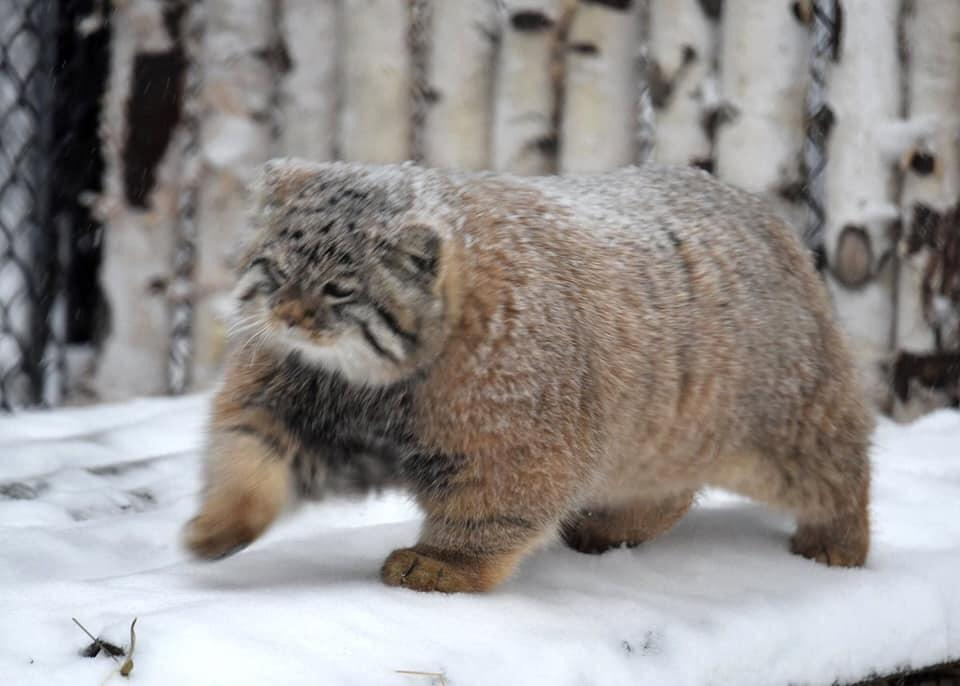

In [6]:
image

In [62]:
image.size

(960, 686)

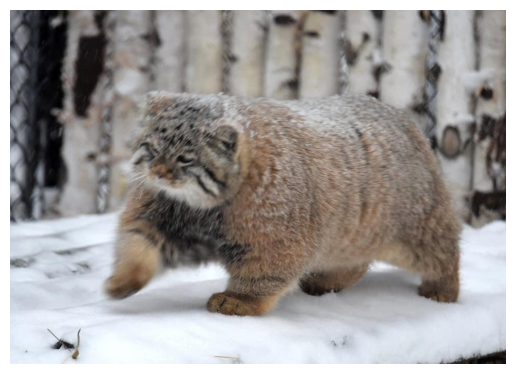

In [7]:
plt.imshow(image)# image with the axis on
plt.axis("off")# keep the axis (x-y) as off
plt.show()

<span style="color:red"> <b> SEGFORMER  using AUTOPROCESSOR </b></span>

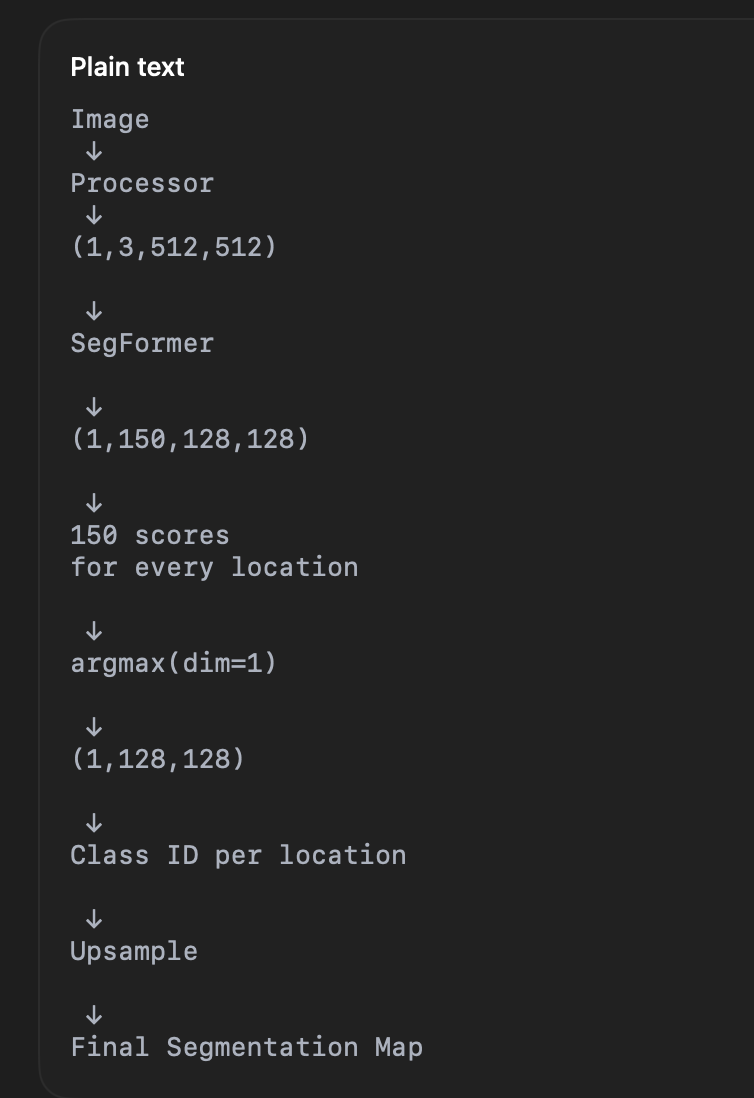

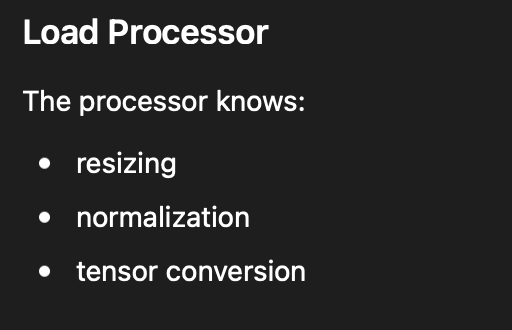

In [8]:
from transformers import AutoProcessor

In [9]:
#Processes the image and makes it into the input format
processor= AutoProcessor.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")

In [10]:
processor

SegformerImageProcessor {
  "do_normalize": true,
  "do_reduce_labels": false,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "SegformerImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "reduce_labels": true,
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 512,
    "width": 512
  }
}

In [11]:
#model loading
from transformers import AutoModelForSemanticSegmentation
model=AutoModelForSemanticSegmentation.from_pretrained( "nvidia/segformer-b0-finetuned-ade-512-512")

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

In [12]:
model

SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (stages): ModuleList(
      (0): SegformerStage(
        (patch_embeddings): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (blocks): ModuleList(
          (0): SegformerLayer(
            (layernorm_before): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
            (attention): SegformerAttention(
              (q_proj): Linear(in_features=32, out_features=32, bias=True)
              (k_proj): Linear(in_features=32, out_features=32, bias=True)
              (v_proj): Linear(in_features=32, out_features=32, bias=True)
              (o_proj): Linear(in_features=32, out_features=32, bias=True)
              (sequence_reduction): SegformerSequenceReduction(
                (sequence_reduction): Conv2d(32, 32, kernel_size=(8, 8), stride=(8, 8))
        

In [13]:
#input prepare
inputs=processor(images=image, return_tensors="pt")
# process these / this image and return it as tensor

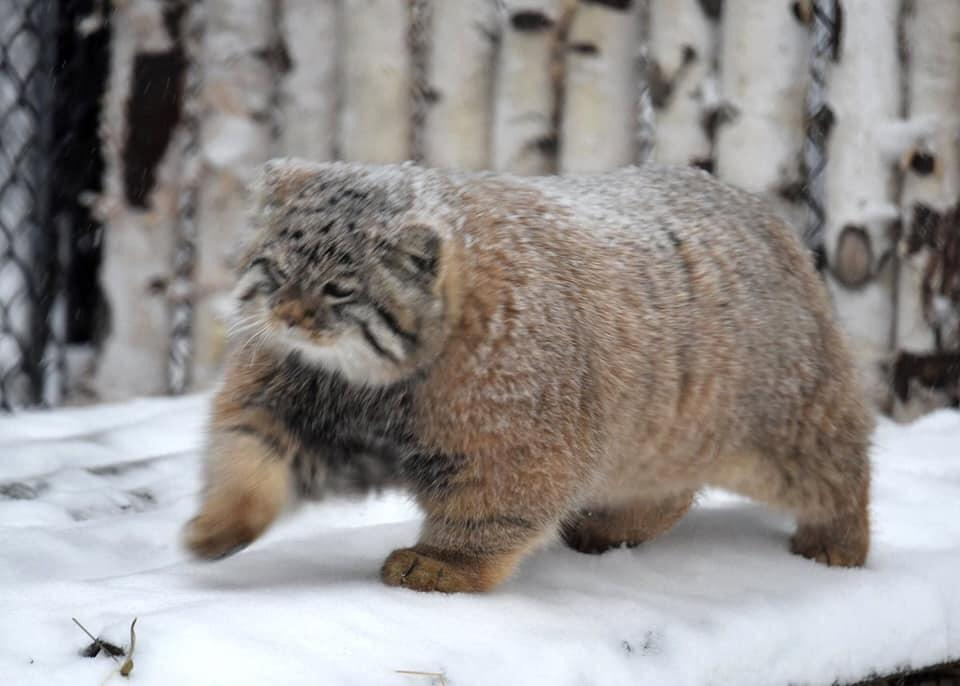

In [15]:
image  

In [17]:
#   image is a tensor aka inputs
inputs

{'pixel_values': tensor([[[[-0.1143, -0.1143, -0.1486,  ...,  0.3823,  0.2796,  0.1939],
          [-0.0458, -0.0629, -0.0972,  ...,  0.3994,  0.2967,  0.2111],
          [-0.0116, -0.0116, -0.0458,  ...,  0.4337,  0.3309,  0.2282],
          ...,
          [ 1.8208,  1.8208,  1.8379,  ..., -1.7583, -1.7240, -1.6384],
          [ 1.8208,  1.8379,  1.8379,  ..., -1.7583, -1.7240, -1.6555],
          [ 1.8379,  1.8379,  1.8550,  ..., -1.7412, -1.7240, -1.6727]],

         [[ 0.0651,  0.0651,  0.0301,  ...,  0.4328,  0.3277,  0.2402],
          [ 0.1352,  0.1176,  0.0826,  ...,  0.4503,  0.3452,  0.2577],
          [ 0.1702,  0.1702,  0.1352,  ...,  0.4853,  0.3803,  0.2752],
          ...,
          [ 2.0959,  2.0959,  2.1134,  ..., -1.7556, -1.7206, -1.6331],
          [ 2.0959,  2.1134,  2.1134,  ..., -1.7556, -1.7206, -1.6506],
          [ 2.1134,  2.1134,  2.1310,  ..., -1.7381, -1.7206, -1.6681]],

         [[ 0.4439,  0.4439,  0.4091,  ...,  0.5834,  0.4788,  0.3916],
          [ 0

In [19]:
type(inputs)

transformers.image_processing_base.BatchFeature

In [18]:
inputs.keys()

KeysView({'pixel_values': tensor([[[[-0.1143, -0.1143, -0.1486,  ...,  0.3823,  0.2796,  0.1939],
          [-0.0458, -0.0629, -0.0972,  ...,  0.3994,  0.2967,  0.2111],
          [-0.0116, -0.0116, -0.0458,  ...,  0.4337,  0.3309,  0.2282],
          ...,
          [ 1.8208,  1.8208,  1.8379,  ..., -1.7583, -1.7240, -1.6384],
          [ 1.8208,  1.8379,  1.8379,  ..., -1.7583, -1.7240, -1.6555],
          [ 1.8379,  1.8379,  1.8550,  ..., -1.7412, -1.7240, -1.6727]],

         [[ 0.0651,  0.0651,  0.0301,  ...,  0.4328,  0.3277,  0.2402],
          [ 0.1352,  0.1176,  0.0826,  ...,  0.4503,  0.3452,  0.2577],
          [ 0.1702,  0.1702,  0.1352,  ...,  0.4853,  0.3803,  0.2752],
          ...,
          [ 2.0959,  2.0959,  2.1134,  ..., -1.7556, -1.7206, -1.6331],
          [ 2.0959,  2.1134,  2.1134,  ..., -1.7556, -1.7206, -1.6506],
          [ 2.1134,  2.1134,  2.1310,  ..., -1.7381, -1.7206, -1.6681]],

         [[ 0.4439,  0.4439,  0.4091,  ...,  0.5834,  0.4788,  0.3916],
    

In [20]:
type(inputs.keys())

collections.abc.KeysView

In [25]:
keys= inputs.keys()

In [63]:
inputs["pixel_values"].size()

torch.Size([1, 3, 512, 512])

<span style="color:green"> <b> FROM (960,686) ITS RESIZED TO (512,512) BY PROCESSOR </b></span>

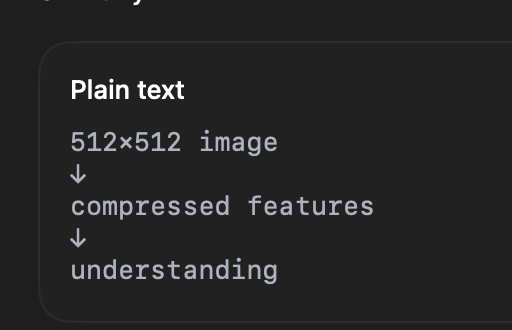

In [29]:
type(inputs["pixel_values"])

torch.Tensor

In [30]:
type(inputs)

transformers.image_processing_base.BatchFeature

In [32]:
dir(inputs)

['_MutableMapping__marker',
 '__abstractmethods__',
 '__class__',
 '__class_getitem__',
 '__contains__',
 '__copy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__ror__',
 '__setattr__',
 '__setitem__',
 '__setstate__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_get_is_as_tensor_fns',
 'clear',
 'convert_to_tensors',
 'copy',
 'data',
 'fromkeys',
 'get',
 'items',
 'keys',
 'pop',
 'popitem',
 'setdefault',
 'skip_tensor_conversion',
 'to',
 'update',
 'values']

<span style="color:yellow"> <b> INFERENCE </b></span>

In [64]:
import torch
with torch.no_grad():
    outputs=model(**inputs)

<span style="color:GREEN"> <b> ** INPUTS PLACES THE TENSOR INSIDE THE MODEL AT APT POSNS </b></span>

In [36]:
outputs

SemanticSegmenterOutput(loss=None, logits=tensor([[[[ -7.0505,  -6.8488,  -7.2320,  ...,  -5.0807,  -4.9755,  -4.8780],
          [ -6.9912,  -7.1360,  -7.4950,  ...,  -5.2550,  -5.0419,  -5.0086],
          [ -7.4676,  -7.8110,  -7.8369,  ...,  -5.4851,  -5.3224,  -5.2922],
          ...,
          [ -9.8179, -10.5792, -10.8845,  ...,  -6.6972,  -6.5999,  -6.3793],
          [ -9.7895, -10.5413, -10.7812,  ...,  -6.5823,  -6.4499,  -6.4879],
          [ -9.5917, -10.6037, -10.7323,  ...,  -6.4787,  -6.5610,  -6.5009]],

         [[ -2.8548,  -2.6478,  -2.7154,  ...,  -3.6473,  -3.4486,  -3.2525],
          [ -2.6147,  -2.8809,  -2.8780,  ...,  -3.6856,  -3.4245,  -3.1496],
          [ -3.1183,  -3.4246,  -3.2372,  ...,  -3.6913,  -3.6226,  -3.3613],
          ...,
          [ -5.9068,  -6.4496,  -6.6636,  ...,  -5.2931,  -5.2028,  -5.0825],
          [ -5.8233,  -6.4306,  -6.5637,  ...,  -5.2216,  -5.1130,  -5.1222],
          [ -5.7612,  -6.3942,  -6.3757,  ...,  -5.1778,  -5.1487,  

In [41]:
type(outputs)

transformers.modeling_outputs.SemanticSegmenterOutput

In [43]:
outputs["logits"]

tensor([[[[ -7.0505,  -6.8488,  -7.2320,  ...,  -5.0807,  -4.9755,  -4.8780],
          [ -6.9912,  -7.1360,  -7.4950,  ...,  -5.2550,  -5.0419,  -5.0086],
          [ -7.4676,  -7.8110,  -7.8369,  ...,  -5.4851,  -5.3224,  -5.2922],
          ...,
          [ -9.8179, -10.5792, -10.8845,  ...,  -6.6972,  -6.5999,  -6.3793],
          [ -9.7895, -10.5413, -10.7812,  ...,  -6.5823,  -6.4499,  -6.4879],
          [ -9.5917, -10.6037, -10.7323,  ...,  -6.4787,  -6.5610,  -6.5009]],

         [[ -2.8548,  -2.6478,  -2.7154,  ...,  -3.6473,  -3.4486,  -3.2525],
          [ -2.6147,  -2.8809,  -2.8780,  ...,  -3.6856,  -3.4245,  -3.1496],
          [ -3.1183,  -3.4246,  -3.2372,  ...,  -3.6913,  -3.6226,  -3.3613],
          ...,
          [ -5.9068,  -6.4496,  -6.6636,  ...,  -5.2931,  -5.2028,  -5.0825],
          [ -5.8233,  -6.4306,  -6.5637,  ...,  -5.2216,  -5.1130,  -5.1222],
          [ -5.7612,  -6.3942,  -6.3757,  ...,  -5.1778,  -5.1487,  -5.2798]],

         [[ -6.7072,  -6.7535,

In [45]:
outputs["logits"].shape

torch.Size([1, 150, 128, 128])

<span style="color: gold"> <b> 150 logits per location .. space is now a 128 x 128 grid with 150 logits per space point </b></span>

In [65]:
preds=outputs.logits.argmax(dim=1)

<span style="color: #18DEDB"> <b> 150 logits per location .. taking the max logit for each location</b></span>

<span style="color:#72DE18"> <b> SOFT MAX IS AN INCREASING FUNCTION so more logit value more its prediction </b></span>

In [68]:
preds

tensor([[[ 1,  1,  1,  ..., 32, 32, 32],
         [ 1,  1,  1,  ..., 32, 32, 32],
         [ 1,  1,  1,  ..., 32, 32, 32],
         ...,
         [13, 13, 13,  ..., 13, 13, 13],
         [13, 13, 13,  ..., 13, 13, 13],
         [13, 13, 13,  ..., 13, 13, 13]]])

In [48]:
loss= outputs.loss

In [71]:
loss
# no loss defined so null

In [70]:
preds.shape

torch.Size([1, 128, 128])

<span style="color:#DE184A"> <b> In PyTorch, image upsampling is the process of increasing the spatial resolution (width and height) of an image or feature map.<br> It is widely used in generative models (like GANs) to build larger images and in segmentation networks (like U-Net) to restore feature maps to original input sizes </b></span>

## <span style="color:#18DE25"> <b> UNSAMPLING </b></span>

In [75]:
import torch.nn.functional as F

# interpolation means estimating values in a given data range
unsampled=F.interpolate(
    preds.unsqueeze(1).float(),
    size=image.size[::-1],## select full height, full width and choose channels on your own (-1 : default) => all
    mode="nearest"
).squeeze()

<span style="color: #f110e2ff"> <b>resolution of unsampled img is lower</b></span>

In [76]:
unsampled

tensor([[ 1.,  1.,  1.,  ..., 32., 32., 32.],
        [ 1.,  1.,  1.,  ..., 32., 32., 32.],
        [ 1.,  1.,  1.,  ..., 32., 32., 32.],
        ...,
        [13., 13., 13.,  ..., 13., 13., 13.],
        [13., 13., 13.,  ..., 13., 13., 13.],
        [13., 13., 13.,  ..., 13., 13., 13.]])

In [77]:
unsampled.shape

torch.Size([686, 960])

In [80]:
from torchvision import transforms
img_tensor=transforms.ToTensor()(image)

In [81]:
unsampled-img_tensor

tensor([[[ 0.5451,  0.5412,  0.5412,  ..., 31.4549, 31.4706, 31.4784],
         [ 0.5333,  0.5333,  0.5333,  ..., 31.4549, 31.4667, 31.4745],
         [ 0.5216,  0.5216,  0.5216,  ..., 31.4471, 31.4627, 31.4706],
         ...,
         [12.0980, 12.0980, 12.0980,  ..., 12.9098, 12.8980, 12.8863],
         [12.0980, 12.0980, 12.0941,  ..., 12.9098, 12.8980, 12.8902],
         [12.0941, 12.0941, 12.0941,  ..., 12.9098, 12.8980, 12.8941]],

        [[ 0.5333,  0.5294,  0.5294,  ..., 31.4745, 31.4902, 31.4980],
         [ 0.5216,  0.5216,  0.5216,  ..., 31.4745, 31.4863, 31.4941],
         [ 0.5098,  0.5098,  0.5098,  ..., 31.4667, 31.4824, 31.4902],
         ...,
         [12.0745, 12.0745, 12.0745,  ..., 12.9294, 12.9176, 12.9059],
         [12.0745, 12.0745, 12.0706,  ..., 12.9294, 12.9176, 12.9098],
         [12.0706, 12.0706, 12.0706,  ..., 12.9294, 12.9176, 12.9137]],

        [[ 0.4980,  0.4941,  0.4941,  ..., 31.4902, 31.5059, 31.5137],
         [ 0.4863,  0.4863,  0.4863,  ..., 31

### <span style="color: #eaea0bff"> <b> diff in the image and the unsampled image tensor</b></span>

# <span style="color: #06e4f8ff"> <b> SEGMENTATION MAP</b></span>

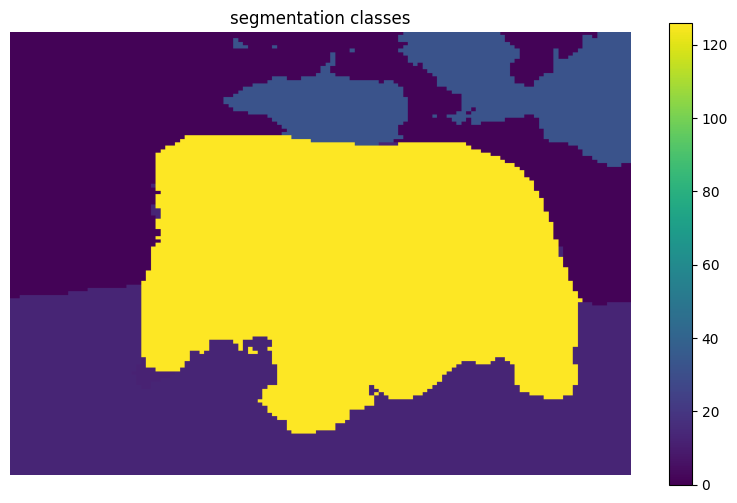

In [97]:
plt.figure(figsize=(10,6))  # size of the display box
plt.imshow(unsampled)   # display image
plt.colorbar()  # uses diff colors for each class
plt.title("segmentation classes")
plt.axis("off")   # no axis
plt.show()  # display

# <span style="color: #eaea0bff"> <b> USING PIPELINE</b></span>

In [83]:
from transformers import pipeline

In [86]:
response=requests.get(url)

In [88]:
img=Image.open(BytesIO(response.content)).convert("RGB")

In [92]:
model= pipeline(task="image-segmentation", model= "nvidia/segformer-b0-finetuned-ade-512-512")


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

In [93]:
results=model(img)

In [95]:
type(results)

list

In [96]:
results

[{'score': None,
  'label': 'wall',
  'mask': <PIL.Image.Image image mode=L size=960x686>},
 {'score': None,
  'label': 'building',
  'mask': <PIL.Image.Image image mode=L size=960x686>},
 {'score': None,
  'label': 'person',
  'mask': <PIL.Image.Image image mode=L size=960x686>},
 {'score': None,
  'label': 'earth',
  'mask': <PIL.Image.Image image mode=L size=960x686>},
 {'score': None,
  'label': 'fence',
  'mask': <PIL.Image.Image image mode=L size=960x686>},
 {'score': None,
  'label': 'animal',
  'mask': <PIL.Image.Image image mode=L size=960x686>}]

## <span style="color: #ea0b0bff"> <b> results has 6 binary (0,1) masks </b></span>